# SAMI-Audio — Interactive demo: timbre transfer

**Deep Learning & Applied AI 2025/26**.  
**SAMI** (Score-based Autoencoder for Multiscale Inference, Lyo et al. 2025)
ported to the audio domain: a variational encoder learns a latent space where
**pitch** and **timbre** are separable with no supervision, and the "decoder" is
the denoiser of a diffusion model guided from the latent.

This notebook is **inference-only**: it trains nothing. It performs the *timbre
transfer* — take a guitar note (A) and make it play with the pitch of a trumpet
(B) — and lets you listen to the result. You only need Python + PyTorch (and the
dependencies in `pyproject.toml`), the two final checkpoints, and the data file
`data/demo_inference_data.npz` (already in the repository).

## What this demo does, in three steps

1. **Loads the two trained models** (both frozen):
   - *MelUNet*: unconditional 2D DDPM denoiser, trained on 61,531 NSynth mel-spectrograms;
   - *MelEncoder*: Half-UNet mapping a mel into a 32-dim latent $(\mu, \sigma^2)$, trained
     with SAMI guidance at frozen denoiser.
2. **Manipulates the latent**: encodes the guitar (A) and the trumpet (B), estimates the
   pitch direction in the latent space (from the data statistics) and *injects* B's pitch
   component into A. The timbre (the part orthogonal to pitch) stays that of A.
3. **Generates**: the denoiser, guided by the manipulated latent, starts from pure noise
   and synthesizes the transfer mel — which you listen to and inspect below, together
   with the two references A and B generated from the *same* initial noise (same seed,
   honest comparison).

## 0. Prerequisites and configuration

Editable cells if you want to try other conditions. The checkpoints must exist at
`checkpoints/nsynth/...` — they are **not** in this repository: download them from the
[GitHub release](https://github.com/Alegau03/progetto-deep/releases) and place them at:

| Download from the release | Rename to |
|---|---|
| `model_final_denoiser.pt` | `checkpoints/nsynth/denoiser_2d/model_final.pt` |
| `model_final_sami.pt` | `checkpoints/nsynth/sami_d32/model_final.pt` |

(the `checkpoints/` directories are created by the cell below). Otherwise the cell
below tells you exactly what is missing.

In [4]:
import os, sys, torch
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.abspath(".")
sys.path.insert(0, ROOT)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CKPT_ENC = "checkpoints/nsynth/sami_d32/model_final.pt"
CKPT_DEN = "checkpoints/nsynth/denoiser_2d/model_final.pt"
DATA_NPZ = "data/demo_inference_data.npz"

# ---- demo parameters (official configuration of the report) ----
S       = 5.0    # guidance scale: how much the noise spectrogram obeys the latent
ALPHA   = 0.3    # fraction of B's pitch injected into A's latent
SEED    = 1006   # initial-noise seed (1006 = the "perfect transfer" case)
N_STEPS = 200    # DDIM steps (as in the final demo)

# Create the target directories so the release files only need to be renamed in place
os.makedirs("checkpoints/nsynth/denoiser_2d", exist_ok=True)
os.makedirs("checkpoints/nsynth/sami_d32", exist_ok=True)

missing = [p for p in (CKPT_ENC, CKPT_DEN, DATA_NPZ) if not os.path.isfile(p)]
if missing:
    raise RuntimeError(
        "\n".join([
            "Missing required files:",
            *["  - " + p for p in missing],
            "",
            "The checkpoints are the trained weights (NOT in this repo): download",
            "them from the GitHub release:",
            "    https://github.com/Alegau03/progetto-deep/releases",
            "then rename and place them at:",
            "    model_final_denoiser.pt -> checkpoints/nsynth/denoiser_2d/model_final.pt",
            "    model_final_sami.pt     -> checkpoints/nsynth/sami_d32/model_final.pt",
        ]))

print(f"Device: {DEVICE}   |   S={S}, alpha={ALPHA}, seed={SEED}, DDIM steps={N_STEPS}")

Device: cpu   |   S=5.0, alpha=0.3, seed=1006, DDIM steps=200


In [5]:
# ---- Model loading (inference only, everything frozen) ----
from models.encoder import MelEncoder
from models.unet import MelUNet
from models.sami import SAMI
from models.losses.diffusion import DiffusionSchedule

ckpt = torch.load(CKPT_ENC, map_location=DEVICE, weights_only=False)
encoder = MelEncoder(in_channels=1, latent_dim=32, base_channels=64,
                     input_size=(128, 256)).to(DEVICE)
sd = {k[len("encoder."):]: v for k, v in ckpt["model_state_dict"].items()
      if k.startswith("encoder.")}
encoder.load_state_dict(sd, strict=True)
encoder.eval()

denoiser = MelUNet(in_channels=1, base_channels=128,
                   channel_mult=(1, 1, 2, 2), time_dim=128).to(DEVICE)
d_ckpt = torch.load(CKPT_DEN, map_location=DEVICE, weights_only=False)
denoiser.load_state_dict(d_ckpt["model_state_dict"])
for p in denoiser.parameters():
    p.requires_grad = False
denoiser.eval()

diffusion = DiffusionSchedule(T=1000, s=0.008).to(DEVICE)
sami = SAMI(encoder, denoiser, diffusion, beta=1e-5,
            frozen_denoiser=True, oversample_t=True, free_bits=0.5).to(DEVICE)

n_enc = sum(p.numel() for p in encoder.parameters()) / 1e6
n_den = sum(p.numel() for p in denoiser.parameters()) / 1e6
print(f"Encoder:  {n_enc:.1f}M params   |   Denoiser: {n_den:.1f}M params")

Encoder:  1.4M params   |   Denoiser: 14.2M params


In [6]:
# ---- Demo data and reference statistics (precomputed on the cluster) ----
from sklearn.neighbors import NearestNeighbors

d = np.load(DATA_NPZ, allow_pickle=True)
xA = torch.from_numpy(d["xA"])          # guitar mel, MIDI 60  (1,128,256)
xB = torch.from_numpy(d["xB"])          # trumpet mel, MIDI 67
wavA0 = torch.from_numpy(d["wavA"])     # original NSynth audio
wavB0 = torch.from_numpy(d["wavB"])

mu_mean, mu_std = d["mu_mean"], d["mu_std"]     # latent standardization
w_pitch = d["w_pitch"]                          # pitch direction (32,)
mu_ref = (d["mu_ref"] - mu_mean) / mu_std       # 8000 reference latents
family_ref = d["family_ref"]                    # 0=brass 1=guitar 2=keyboard 3=string
knn = NearestNeighbors(n_neighbors=5).fit(mu_ref)

metaA = dict(d["metaA"].item()); metaA.pop("qualities", None)
metaB = dict(d["metaB"].item()); metaB.pop("qualities", None)
print("meta A:", metaA)
print("meta B:", metaB)

meta A: {'entry_id': 'guitar_acoustic_019-060-075', 'pitch': 60, 'instrument_family': 'guitar', 'instrument_family_int': 3, 'instrument_source': 0, 'velocity': 75, 'sample_rate': 16000, 'note_str': 'guitar_acoustic_019-060-075'}
meta B: {'entry_id': 'brass_acoustic_027-067-100', 'pitch': 67, 'instrument_family': 'brass', 'instrument_family_int': 1, 'instrument_source': 0, 'velocity': 100, 'sample_rate': 16000, 'note_str': 'brass_acoustic_027-067-100'}


## 1. The two starting notes

**Real** NSynth audio (not generated by the model): A = guitar, MIDI 60 (middle C),
B = trumpet, MIDI 67 (G). Listen to them: these are the two notes the demo combines.

In [7]:
try:
    from IPython.display import Audio, display
except ImportError:
    # Fallback if the notebook runs outside Jupyter (e.g. as a script):
    def display(*args, **kwargs):
        print("[IPython not available: inline audio playback skipped]")
    class Audio:
        def __init__(self, *a, **k): pass
SR = 16000

print("A — guitar, MIDI 60 (C):")
display(Audio(data=wavA0[0].numpy(), rate=SR))
print("B — trumpet, MIDI 67 (G):")
display(Audio(data=wavB0[0].numpy(), rate=SR))

A — guitar, MIDI 60 (C):


B — trumpet, MIDI 67 (G):


## 2. The latent manipulation

The encoder maps every mel into a 32-dim latent. Without labels, the training
produced a direction $w_{\text{pitch}}$ that controls almost only pitch. The operation:

- $\mu_A^s = (\mu_A - \mu_{\text{mean}}) / \mu_{\text{std}}$ (A's standardized latent),
- *subtract* A's own pitch component and *add* B's pitch component weighted by
  $\alpha$:  $\mu_T^s = \mu_A^s - \text{proj}_{w}(\mu_A^s) + \alpha\,\text{proj}_{w}(\mu_B^s)$.

With $\alpha=0.3$ B's pitch is enough to move the fundamental but not enough to corrupt
the timbre: this is the operating point of the report.

In [8]:
with torch.no_grad():
    muA, _ = encoder(xA.to(DEVICE))
    muB, _ = encoder(xB.to(DEVICE))

muA_s = (muA.cpu().numpy()[0] - mu_mean) / mu_std
muB_s = (muB.cpu().numpy()[0] - mu_mean) / mu_std

compA = np.dot(muA_s, w_pitch) * w_pitch      # A's pitch component
compB = np.dot(muB_s, w_pitch) * w_pitch      # B's pitch component

muT_s = muA_s - compA + ALPHA * compB         # timbre of A, pitch of B
muT_v = muT_s * mu_std + mu_mean              # de-standardize for sampling

print("projection onto w_pitch:  A = %.3f   B = %.3f   T = %.3f" % (
    np.dot(muA_s, w_pitch), np.dot(muB_s, w_pitch), np.dot(muT_s, w_pitch)))
print("T = guitar latent with the trumpet pitch (alpha=%.1f)" % ALPHA)

projection onto w_pitch:  A = 1.699   B = 2.166   T = 0.650
T = guitar latent with the trumpet pitch (alpha=0.3)


## 3. Generation with the guided denoiser

The cell below does three things, in plain terms:

1. **Draws an initial noise** $x_T$ — the *same* tensor for A, T and B (same seed),
   so the comparison is fair: any difference between the three notes is
   attributable to the latent, not to the noise.
2. **Runs 200 DDIM denoising steps.** At each step the denoiser predicts the noise
   to remove, and that prediction is *deviated* by the latent gradient (guidance),
   which steers the generated sound toward the conditioning latent $z$:

$$\hat{\varepsilon}(x_t, t, z) = \varepsilon_\theta(x_t, t) - s\cdot\gamma_t\cdot
\nabla_{x_t} \log q_\varphi(z | x_t)$$

   With $s=5$ the guidance is strong enough to imprint the pitch on the output.
3. **Decodes** each resulting mel back into audio with Griffin-Lim (next section).

You will then have **three generated notes**, all starting from the same initial noise:

| Note | Guided by | What it represents |
|---|---|---|
| **A gen** | $z_A$ (guitar) | the reference: a generated guitar note at pitch A |
| **T gen** | $z_T$ (guitar timbre + trumpet pitch) | **the transfer** — the object of the demo |
| **B gen** | $z_B$ (trumpet) | the reference: a generated trumpet note at pitch B |

Listen to **T** in between **A** and **B**: it should have the trumpet's pitch (G, ~392 Hz)
on the guitar's timbre. If it does, the latent separation worked: pitch and timbre were
moved independently, without supervision.

Timings measured on the DI Sapienza submitter (CPU): ~0.4 s per step → about 1.5 min per
note, ~4-5 min for the three (a few seconds per note on GPU). Just run the cell and wait.

In [9]:
def generate(mu_v, seed):
    # Generates a mel (1,128,256) with the denoiser guided by latent mu_v.
    g = torch.Generator(device=DEVICE)
    g.manual_seed(seed)
    with torch.no_grad():
        return sami.sample_seeded(
            torch.from_numpy(mu_v).unsqueeze(0).to(DEVICE),
            (1, 128, 256), n_steps=N_STEPS, generator=g,
            guidance_scale=S)

print(f"Generating A, T, B with seed={SEED} (S={S}, alpha={ALPHA})...")
xgenA = generate(muA.cpu().numpy()[0], SEED)
xgenT = generate(muT_v, SEED)
xgenB = generate(muB.cpu().numpy()[0], SEED)
print("Done.")

Generating A, T, B with seed=1006 (S=5.0, alpha=0.3)...
Done.


## 4. Listen to the result

For the chosen seed (1006) the transfer is **complete**: T has B's pitch (G, ~392 Hz)
but the guitar timbre. Compare T with A (same guitar, lower pitch) and with B (trumpet,
same pitch). Note: the sound is reconstructed from the mel with Griffin-Lim — it sounds
"vintage", but the pitch and the timbre are clearly recognizable.

In [10]:
from data.nsynth import mel_to_audio

wavA = mel_to_audio(torch.from_numpy(xgenA[0, 0].numpy()).unsqueeze(0))
wavT = mel_to_audio(torch.from_numpy(xgenT[0, 0].numpy()).unsqueeze(0))
wavB = mel_to_audio(torch.from_numpy(xgenB[0, 0].numpy()).unsqueeze(0))

print("A gen — guitar (pitch A):")
display(Audio(data=wavA[0].numpy(), rate=SR))
print("T gen — TRANSFER: pitch of B, timbre of A:")
display(Audio(data=wavT[0].numpy(), rate=SR))
print("B gen — trumpet (pitch B):")
display(Audio(data=wavB[0].numpy(), rate=SR))

A gen — guitar (pitch A):


T gen — TRANSFER: pitch of B, timbre of A:


B gen — trumpet (pitch B):


/tmp/ipykernel_915126/1733301811.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


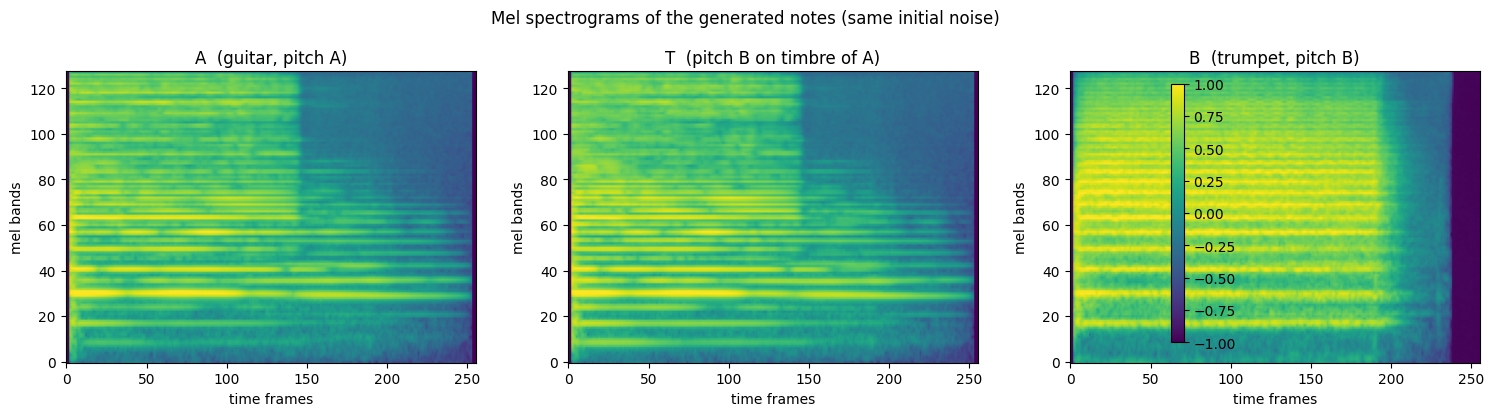

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, x, title in zip(axes, [xgenA, xgenT, xgenB], ["A  (guitar, pitch A)",
                                                      "T  (pitch B on timbre of A)",
                                                      "B  (trumpet, pitch B)"]):
    im = ax.imshow(x[0, 0].cpu().numpy(), aspect="auto", origin="lower",
                   cmap="viridis", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("time frames")
    ax.set_ylabel("mel bands")
fig.suptitle("Mel spectrograms of the generated notes (same initial noise)")
fig.colorbar(im, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

## 5. Variability across noise seeds

The transfer does not succeed for every initial noise: the guidance, however strong,
does not always win over the sampled $x_T$ (this limit is documented in the report,
"Outcome B"). Out of 7 tested seeds, 3 produced a complete transfer. This cell repeats
the generation for a few seeds and **measures** the results instead of trusting the ear.

**How the measurement works — two independent checks on the *generated* output:**

1. **Pitch — CREPE** (Kim et al., ICASSP 2018): a convolutional network trained on
   massive amounts of human-labeled audio to estimate the *fundamental frequency*
   (f0) of a note, frame by frame. We use it to ask: *"what pitch does the generated
   note actually sound at?"* It is the fair referee — we cannot just check what we
   injected into the latent, we must verify what came out. For each generated note
   we report the median f0 over frames with confidence > 0.5:
   - if **T's f0 is closer to B's f0 than to A's f0**, the pitch really moved → the
     transfer worked on the pitch side;
   - if f0 is missing (no frames above confidence), the note is too noisy/unpitched
     to be measured, and that seed is not counted (honest denominator).
2. **Timbre — re-encoder + k-NN**: the transfer must not just change the pitch, it
   must *keep the guitar timbre*. We re-encode the generated T with the same encoder
   and look at its latent neighbors among 8000 real NSynth notes (k-NN, 5 neighbors).
   The **majority vote of the neighbors' instrument families** is the predicted timbre:
   - if the majority is *guitar*, the timbre survived → the transfer worked on the
     timbre side;
   - if it is *brass*, the pitch dragged the timbre with it → partial failure.

**Success criterion (both, on valid seeds):** pitch moved toward B AND timbre voted
guitar. This is the same protocol used for the official 3/7 result.

If `torchcrepe` is not installed, the pitch measurement is skipped (it is needed for
the count; the timbre check still runs).

In [12]:
# Lower this list (or N_STEPS in cell 0) if you want to wait less.
SEEDS = [1000, 1001, 1002, 1006]

try:
    import torchcrepe
    HAVE_CREPE = True
except ImportError:
    HAVE_CREPE = False
    print("[INFO] torchcrepe not installed: pitch measurement will be skipped.")

CONF_THRESH = 0.5
GUITAR = 1  # label-encoded family: 0=brass 1=guitar 2=keyboard 3=string
label_names = {0: "brass", 1: "guitar", 2: "keyboard", 3: "string"}


def crepe_f0(wav, device=DEVICE):
    out = torchcrepe.predict(wav.reshape(1, -1), SR, hop_length=256,
                             fmin=50, fmax=2000, model="full",
                             batch_size=64, device=device,
                             return_periodicity=True)
    if isinstance(out, tuple):
        f0, conf = out[0], out[1]
    else:
        f0, conf = out, torch.ones_like(out)
    f0_np, conf_np = f0[0].cpu().numpy(), conf[0].cpu().numpy()
    mask = ~np.isnan(f0_np) & (conf_np > CONF_THRESH)
    if mask.sum() < 5:
        return float("nan")
    return float(np.median(f0_np[mask]))


def classify_timbre(xgen):
    # Re-encodes the generated mel and votes the timbre with k-NN (majority over 5 neighbors).
    with torch.no_grad():
        mu, _ = encoder(xgen.to(DEVICE))
    mu_v = (mu.cpu().numpy()[0] - mu_mean) / mu_std
    _, inds = knn.kneighbors(mu_v.reshape(1, -1))
    votes = [family_ref[i] for i in inds[0]]
    return max(set(votes), key=votes.count), votes


rows = []
for seed in SEEDS:
    xA_s = generate(muA.cpu().numpy()[0], seed)
    xT_s = generate(muT_v, seed)
    xB_s = generate(muB.cpu().numpy()[0], seed)
    wA, wT, wB = (mel_to_audio(torch.from_numpy(x[0, 0].numpy()).unsqueeze(0))
                  for x in (xA_s, xT_s, xB_s))
    if HAVE_CREPE:
        fA, fT, fB = crepe_f0(wA), crepe_f0(wT), crepe_f0(wB)
    else:
        fA = fT = fB = float("nan")
    maj, votes = classify_timbre(xT_s)
    rows.append((seed, fA, fT, fB, maj, votes))
    print("seed %4d  f0_A=%6.1f  f0_T=%6.1f  f0_B=%6.1f  timbreT=%s  votes=%s" % (
        seed, fA, fT, fB, label_names[maj],
        [label_names[v] for v in votes]))

valid = [r for r in rows if not any(np.isnan(x) for x in (r[1], r[2], r[3]))]
ok = sum(1 for _, fA, fT, fB, maj, _ in valid
         if abs(fT - fB) < abs(fT - fA) and maj == GUITAR)
print()
print(f"=> complete transfers: {ok}/{len(valid)} valid seeds "
      f"({len(rows) - len(valid)} with unmeasurable pitch)")

/home/romitoskj/Projects/progetto-deep/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


seed 1000  f0_A= 165.8  f0_T= 165.6  f0_B= 445.3  timbreT=guitar  votes=['guitar', 'guitar', 'guitar', 'guitar', 'guitar']
seed 1001  f0_A= 467.5  f0_T=   nan  f0_B=   nan  timbreT=guitar  votes=['guitar', 'guitar', 'guitar', 'guitar', 'guitar']
seed 1002  f0_A= 306.0  f0_T= 208.8  f0_B= 309.0  timbreT=guitar  votes=['guitar', 'guitar', 'guitar', 'guitar', 'guitar']
seed 1006  f0_A= 294.6  f0_T= 294.6  f0_B= 294.7  timbreT=guitar  votes=['guitar', 'guitar', 'guitar', 'guitar', 'guitar']

=> complete transfers: 1/3 valid seeds (1 with unmeasurable pitch)
